In [1]:
import sys
import os

# # Add the current file’s directory (or parent) to sys.path
# sys.path.append(os.path.dirname(os.path.abspath(__file__)))
# OR, if you’re in a Jupyter notebook:
# Go up two levels from the current working directory
parent_dir = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

# Add that directory to Python's import path
sys.path.append(parent_dir)

In [2]:
import yaml
import torch
import sys, os

# Go to project root (two parents up from tests/)
project_root = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.append(project_root)

# Import
from src.blocks.SpectogramBlock import SpectrogramBlock


# Load YAML
with open("../../configs/spectogram.yaml", "r") as f:
    cfg = yaml.safe_load(f)

# Extract parameters
params = cfg["model"]["blocks"][0]["params"]

# Build the block
model = SpectrogramBlock(**params)




In [3]:
import torchaudio
import random
from pathlib import Path

# --- Load a random example audio file ---
examples_dir = Path("../../example").resolve()
wav_files = list(examples_dir.glob("*.wav"))
if not wav_files:
    raise FileNotFoundError(f"No .wav files found in {examples_dir}")

random_file = random.choice(wav_files)
print(f"🎵 Using random file: {random_file.name}")

waveform, sr = torchaudio.load(random_file)

🎵 Using random file: rock-garage_example.wav


/opt/anaconda3/envs/audio-filler/lib/python3.11/site-packages/torchaudio/_backend/utils.py:213: UserWarning: In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec` under the hood. Some parameters like ``normalize``, ``format``, ``buffer_size``, and ``backend`` will be ignored. We recommend that you port your code to rely directly on TorchCodec's decoder instead: https://docs.pytorch.org/torchcodec/stable/generated/torchcodec.decoders.AudioDecoder.html#torchcodec.decoders.AudioDecoder.
  warnings.warn(


In [4]:
# Run a test
x = waveform  # Add batch dimension: (1, 1, num_samples)
spec_dict = model(x)

print(spec_dict.keys())  # Should show the keys in the output dictionary

dict_keys(['freq_spec', 'time_spec', 'recon_spec'])


In [5]:
for key, value in spec_dict.items():
    print(f"{key}: {value.shape}")

freq_spec: torch.Size([1, 3, 2001, 201])
time_spec: torch.Size([1, 3, 501, 801])
recon_spec: torch.Size([1, 3, 1001, 401])


In [6]:
import matplotlib.pyplot as plt
import torch

def visualize_spectrogram_parts(spectrogram, title="Spectrogram"):
    """
    Visualizes the real, imaginary, and log-magnitude parts of a spectrogram.
    Works with shape (B, 3, F, T) or (3, F, T).
    Displays each as a separate figure.
    """
    # --- Handle batch dimension ---
    if spectrogram.ndim == 4:  # (B, 3, F, T)
        spectrogram = spectrogram[0]
    elif spectrogram.ndim != 3:
        raise ValueError("Expected spectrogram shape (B, 3, F, T) or (3, F, T).")

    if spectrogram.shape[0] != 3:
        raise ValueError("Spectrogram must have 3 channels: real, imag, log-magnitude.")

    real_part = spectrogram[0].cpu().numpy()
    imag_part = spectrogram[1].cpu().numpy()
    log_mag = spectrogram[2].cpu().numpy()

    # --- Real part ---
    plt.figure(figsize=(10, 4))
    plt.imshow(real_part, origin='lower', aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.title(f"{title} - Real Part")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()

    # --- Imaginary part ---
    plt.figure(figsize=(10, 4))
    plt.imshow(imag_part, origin='lower', aspect='auto', cmap='coolwarm')
    plt.colorbar()
    plt.title(f"{title} - Imaginary Part")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()

    # --- Log Magnitude ---
    plt.figure(figsize=(10, 4))
    plt.imshow(log_mag, origin='lower', aspect='auto', cmap='magma')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"{title} - Log Magnitude (dB)")
    plt.xlabel("Time Frames")
    plt.ylabel("Frequency Bins")
    plt.tight_layout()
    plt.show()


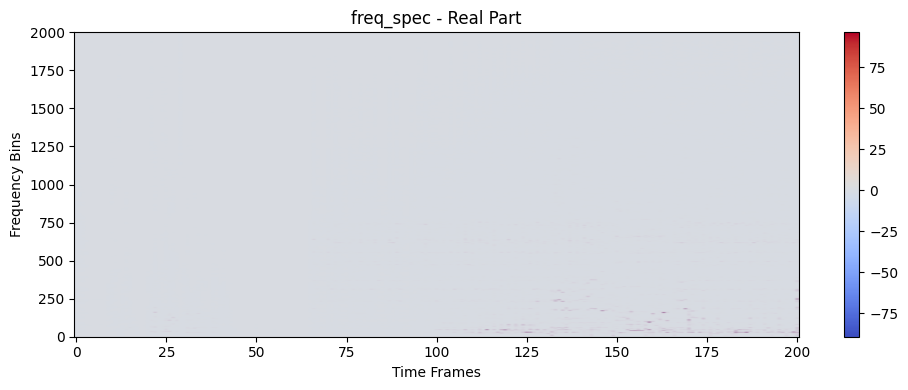

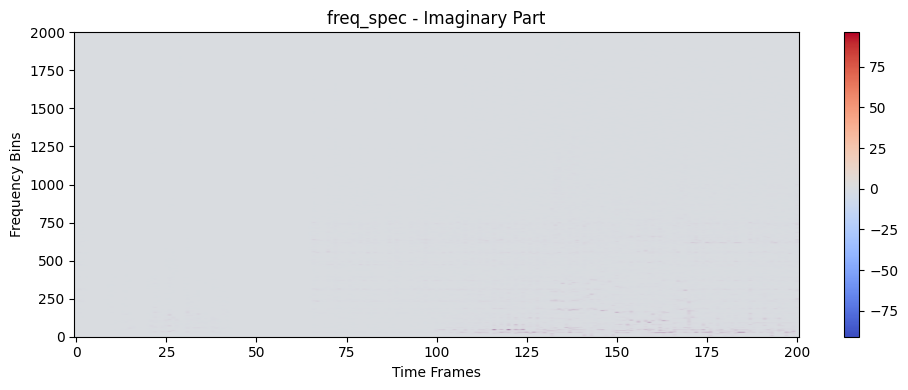

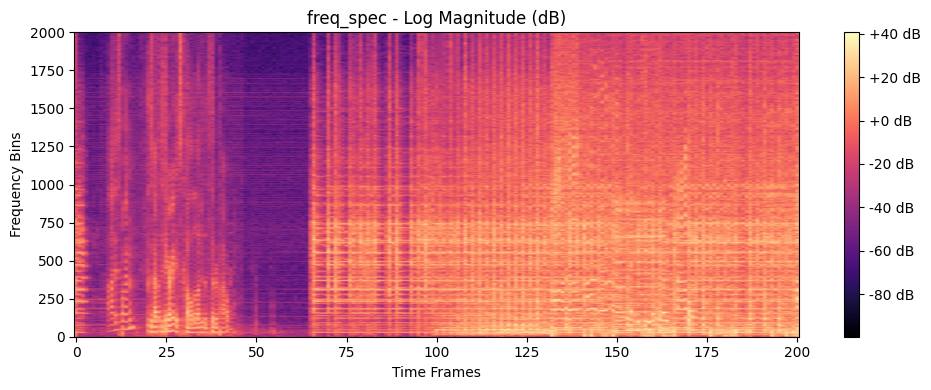

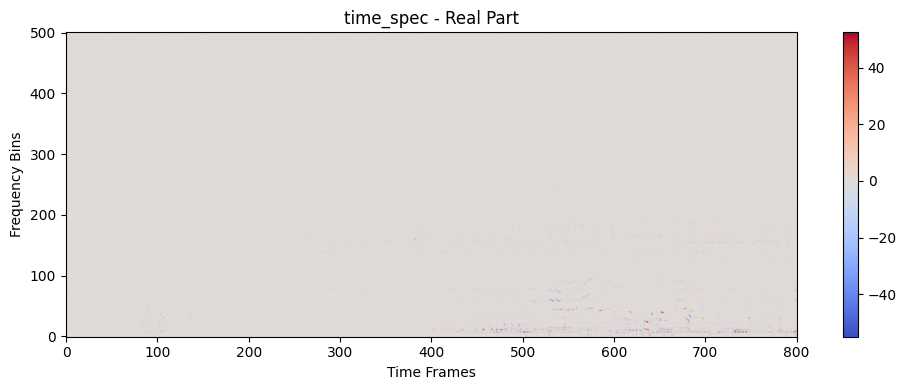

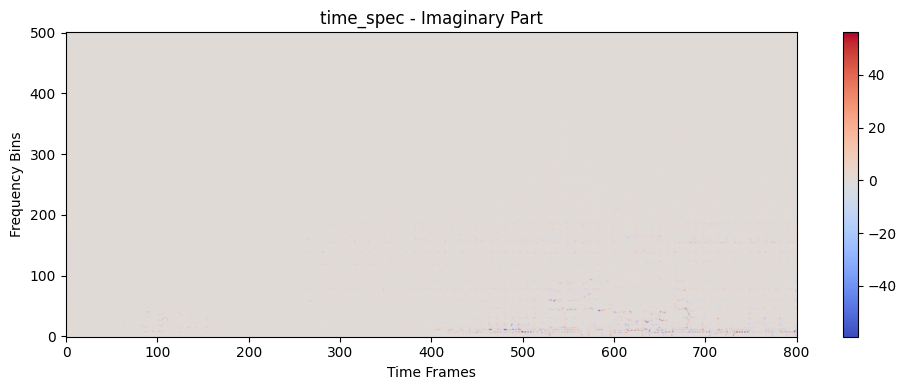

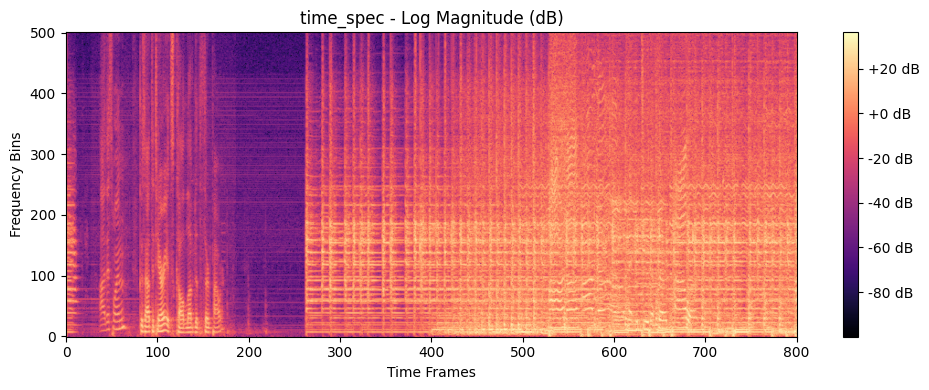

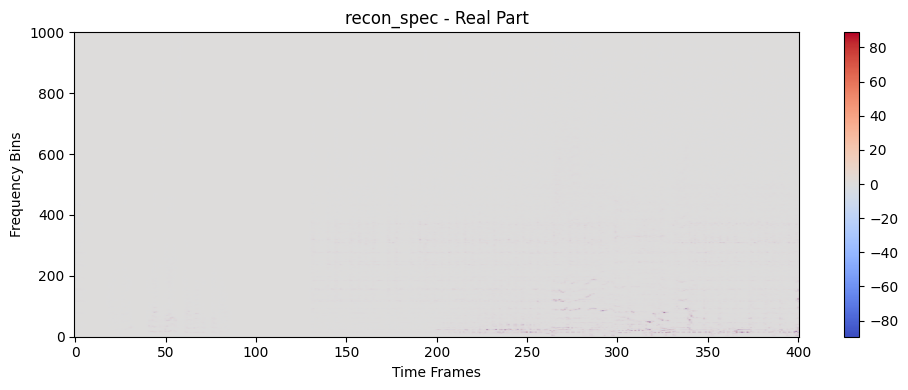

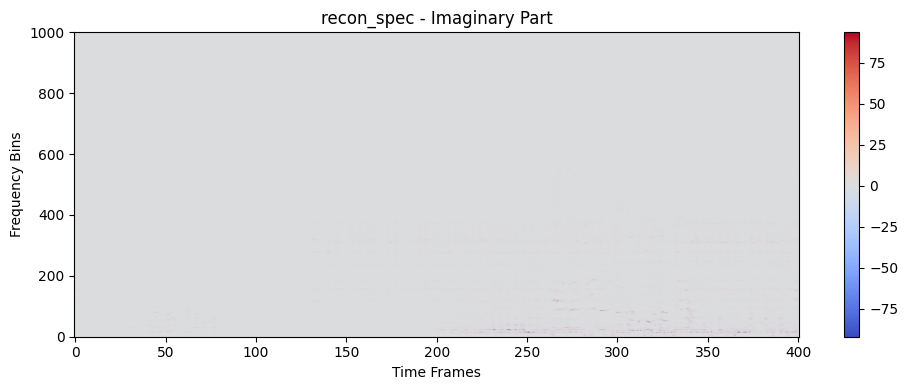

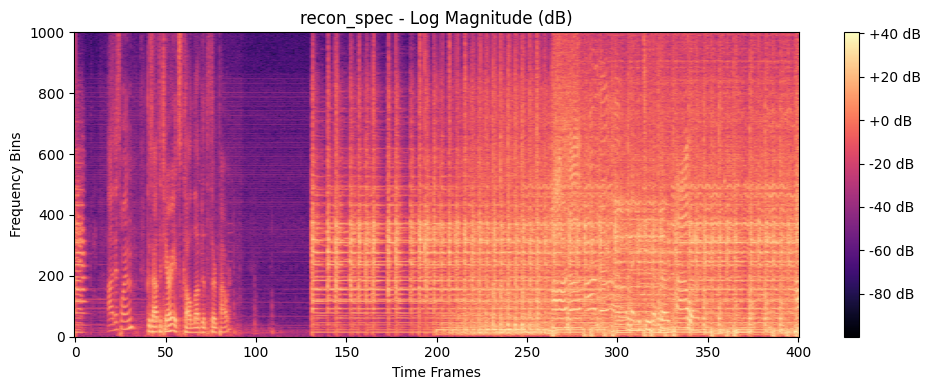

In [7]:

for key, value in spec_dict.items():
    # if key == "recon_wave":  # skip waveform
    #     continue
    visualize_spectrogram_parts(value, title=key)



In [8]:
spec_dict['freq_spec']

tensor([[[[ 8.7951e-01, -2.6599e-02,  4.4344e-04,  ...,  1.8796e+00,
            1.5732e-01, -1.1217e+01],
          [-8.8205e-01,  2.4223e-02, -7.8255e-03,  ..., -1.8627e+00,
            3.0708e-01,  1.1607e+01],
          [ 8.9162e-01, -1.6510e-02,  2.4401e-02,  ...,  1.6661e+00,
           -1.6409e+00, -1.1487e+01],
          ...,
          [-6.9574e-02,  3.3127e-03, -8.2580e-04,  ...,  1.7820e-02,
           -4.3291e-02,  1.9505e+00],
          [ 7.2832e-02, -2.8346e-03,  7.6099e-04,  ..., -2.5219e-03,
           -4.5326e-02, -2.5652e+00],
          [-7.4067e-02,  2.5115e-03, -7.5337e-04,  ..., -1.1563e-02,
            9.3194e-02,  2.7978e+00]],

         [[ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 4.7223e-08, -1.5025e-02, -2.0068e-02,  ..., -1.6401e-01,
            9.0215e-01,  2.3950e-02],
          [-1.6423e-08,  2.3311e-02,  3.8616e-02,  ...,  2.2755e-01,
           -1.0538e+00, -3.6938e-02],
          ...,
     

In [9]:
from src.blocks.InvSpecBlock import InvSpecBlock
# Load YAML
with open("../../configs/invspec.yaml", "r") as f:
    cfg_1 = yaml.safe_load(f)

params1 = cfg_1["model"]["blocks"][0]["params"]

invmodel = InvSpecBlock(**params1)

In [10]:
recon_spec = spec_dict["recon_spec"]  # shape: (B, 3, F, T)


recon_spec_2ch = recon_spec[:, :2, :, :]  # (B, 2, F, T)


reconstructed_waveform = invmodel(recon_spec_2ch)

print("Reconstructed waveform shape:", reconstructed_waveform.shape)

Reconstructed waveform shape: torch.Size([1, 1, 240000])


In [11]:
from IPython.display import Audio
Audio(reconstructed_waveform[0].cpu().numpy(), rate=sr)

In [12]:
from src.blocks.ConvBlock import ConvBlock

# Load YAML
with open("../../configs/conv_block.yaml", "r") as f:
    cfg_conv = yaml.safe_load(f)

print(cfg_conv)

{'model': {'name': 'ConvBlock', 'blocks': [{'id': 'ConvLayer', 'type': 'conv_layer_basic', 'params': {'in_channels': 3, 'out_channels': 4, 'kernel_size': 3, 'stride': 1, 'padding': 1, 'activation': 'ReLU', 'batch_norm': True}}, {'id': 'ConvLayer2', 'type': 'conv_layer_basic', 'params': {'in_channels': 4, 'out_channels': 8, 'kernel_size': 5, 'stride': 1, 'padding': 2, 'activation': 'LeakyReLU', 'batch_norm': True}}, {'id': 'ConvLayerFreq', 'type': 'conv_layer_squish_freq', 'params': {'in_channels': 11, 'out_channels': 4, 'kernel_size': '(5, 3)', 'stride': '(4, 1)', 'padding': '(2, 1)', 'activation': 'ReLU', 'batch_norm': True}}, {'id': 'ConvLayerTime', 'type': 'conv_layer_squish_time', 'params': {'in_channels': 11, 'out_channels': 4, 'kernel_size': '(3, 5)', 'stride': '(1, 4)', 'padding': '(1, 2)', 'activation': 'LeakyReLU', 'batch_norm': True}}]}}


In [13]:
conv1 = ConvBlock(cfg_conv['model']['blocks'][0]['params'])

In [14]:
freq_spec = spec_dict['freq_spec']  # (B, 1, F, T)
time_spec = spec_dict['time_spec']  # (B, 1, F, T)

conv_freq = conv1(freq_spec)
print("Conv on freq_spec output shape:", conv_freq.shape)

conv_time = conv1(time_spec)
print("Conv on time_spec output shape:", conv_time.shape)

Conv on freq_spec output shape: torch.Size([1, 4, 2001, 201])
Conv on time_spec output shape: torch.Size([1, 4, 501, 801])


In [15]:
conv2 = ConvBlock(cfg_conv['model']['blocks'][1]['params'])

conv_f = ConvBlock(cfg_conv['model']['blocks'][2]['params'])
conv_t = ConvBlock(cfg_conv['model']['blocks'][3]['params']
                   )

In [16]:
conv_freq = conv2(conv_freq)
print("Conv2 on conv_freq output shape:", conv_freq.shape)
conv_time = conv2(conv_time)
print("Conv2 on conv_time output shape:", conv_time.shape)

conv_freq = torch.cat([conv_freq, freq_spec], dim=1)
conv_time = torch.cat([conv_time, time_spec], dim=1)

print("After concatenation:")
print("conv_freq shape:", conv_freq.shape)
print("conv_time shape:", conv_time.shape)

conv_freq = conv_f(conv_freq)
print("Conv_f on conv_freq output shape:", conv_freq.shape)
conv_time = conv_t(conv_time)
print("Conv_t on conv_time output shape:", conv_time.shape)

Conv2 on conv_freq output shape: torch.Size([1, 8, 2001, 201])
Conv2 on conv_time output shape: torch.Size([1, 8, 501, 801])
After concatenation:
conv_freq shape: torch.Size([1, 11, 2001, 201])
conv_time shape: torch.Size([1, 11, 501, 801])
Conv_f on conv_freq output shape: torch.Size([1, 4, 501, 201])
Conv_t on conv_time output shape: torch.Size([1, 4, 501, 201])
